In [1]:
import skimage
import sklearn
import re
import shutil
import numpy as np
import serial
import time
import matplotlib.pyplot as plt
import ipdb
from ipywidgets import IntProgress
from IPython.display import display
from math import floor
from matplotlib.colors import LinearSegmentedColormap
from tqdm.notebook import tqdm
from time import sleep
import lifefit as lf
import seaborn as sns
import os





def plot_histograms_as_image_argmax(histograms, width):
    """
    Plot histograms as an image where the brightness of each pixel
    is determined by the index of the maximum bin in its histogram.

    Args:
        histograms (dict): Dictionary where keys are pixel indices and values are histogram arrays.
        n_rows (int): Number of rows in the image.
        n_cols (int): Number of columns in the image.

    Returns:
        None (displays the image using matplotlib).
    """
    # Initialize an empty image array
    image = np.zeros((width, width), dtype=np.uint32)
    pixel_values = []

    # Fill the image array with the max bin indices
    for pixel, histogram in enumerate(histograms):
        if pixel >= width * width:
            print(f"Warning: Pixel {pixel} exceeds image dimensions ({width}x{width}). Skipping.")
            continue



        # Find the index of the maximum bin value
        max_bin_index = np.argmax(histogram)
        
        max_bin_ps = max_bin_index * bin_width  # convert from bins to ps

        # Normalize the max bin index to 0-255 for grayscale
        # (Assuming histogram bins are in a reasonable range, e.g., 0-35)
        #normalized_brightness = int((max_bin_index / len(histogram)) * 255)
        pixel_values.append(max_bin_ps)
        
                # Calculate row and column from pixel index
        row = pixel // width
        col = pixel % width
        #image[row, col] = pixel_values[pixel]*255/max_value
        image[row, col] = max_bin_ps

        
    max_value = max(pixel_values)
    min_value = min(pixel_values)
        


    # Plot the image
    plt.figure(figsize = (20,20))
    #plt.imshow(image, cmap="gray", vmin=min(pixel_values), vmax=max(pixel_values))
    plt.imshow(image, cmap="gray", vmin=min_value, vmax=max_value)
    plt.colorbar(label="Maximum Bin (ps)")
    plt.title("Image Reconstructed from Histograms")
    plt.show()

    return image


def median_bin_interpolated(bins, counts):
    total = np.sum(counts)
    target = 0.5 * total
    cum_counts = np.cumsum(counts)
    # Find the bin where cumulative count crosses target
    median_bin_index = np.argmax(cum_counts >= target)
    if cum_counts[median_bin_index] == target:
        # Exact match: median is the upper edge of the bin
        return median_bin_index, bins[median_bin_index + 1]
    else:
        # Interpolate within the bin
        counts_so_far = cum_counts[median_bin_index - 1] if median_bin_index > 0 else 0
        count_in_bin = counts[median_bin_index]
        fraction = (target - counts_so_far) / count_in_bin
        lower_edge = bins[median_bin_index]
        upper_edge = bins[median_bin_index + 1]
        median_value = lower_edge + fraction * (upper_edge - lower_edge)
        return median_bin_index, median_value


def plot_histograms_as_image_center_of_mass(histograms, width):
    """
    Plot histograms as an image where the brightness of each pixel
    is determined by the index of the center of mass of its histogram.

    Args:
        histograms (dict): Dictionary where keys are pixel indices and values are histogram arrays.
        n_rows (int): Number of rows in the image.
        n_cols (int): Number of columns in the image.

    Returns:
        None (displays the image using matplotlib).
    """
    # Initialize an empty image array
    image = np.zeros((width, width), dtype=np.uint32)
    pixel_values = []

    # Fill the image array with the max bin indices
    for pixel, histogram in enumerate(histograms):
        if pixel >= width * width:
            print(f"Warning: Pixel {pixel} exceeds image dimensions ({width}x{width}). Skipping.")
            continue

        # Calculate row and column from pixel index
        row = pixel // width
        col = pixel % width

        # Find the index of the maximum bin value
        #max_bin_index = np.argmax(histogram)
        
        weights = np.array(histogram)
        bins = np.arange(histogram.size)
        
        _, CoM = median_bin_interpolated(bins, weights)
        
        CoM = CoM * bin_width  # convert from bins to ps

        # Normalize the max bin index to 0-255 for grayscale
        # (Assuming histogram bins are in a reasonable range, e.g., 0-35)
        #normalized_brightness = int((max_bin_index / len(histogram)) * 255)
        pixel_values.append(CoM)
        image[row, col] = CoM

    # Plot the image
    plt.figure(figsize = (20,20))
    plt.imshow(image, cmap="gray", vmin=min(pixel_values), vmax=max(pixel_values))
   #plt.imshow(image, cmap="gray", vmin=min(pix, vmax=255)
   # cbar = plt.colorbar(label="Center of Histogram Mass (ps)")
    cbar = plt.colorbar()
    cbar.set_label("Center of Histogram Mass (ps)", fontsize=25)
    cbar.ax.tick_params(labelsize=17)
    plt.title("Image Reconstructed from Histograms", fontsize=25)
    plt.savefig("image.png")

    plt.show()

    return image   

In [2]:


def display_rgb_color(rgb, size=100, title=None):
    """
    Display a solid RGB color in a small plot.

    Parameters:
    -----------
    rgb : array-like or tuple
        RGB color values. Can be:
        - Normalized to [0, 1] (e.g., (0.5, 0.2, 0.8))
        - In the range [0, 255] (e.g., (128, 51, 204))
    size : int, optional
        Size of the color patch in pixels (default: 100).
    title : str, optional
        Title for the plot (default: None).
    """
    # Convert RGB to a 1x1 image
    if np.max(rgb) > 1:
        rgb = np.array(rgb, dtype=np.float32) / 255.0  # Normalize to [0, 1]

    # Create a 1x1x3 array for the color
    color_patch = np.array([[[rgb[0], rgb[1], rgb[2]]]])

    # Create a figure and display the color
    fig, ax = plt.subplots(figsize=(size/100, size/100), dpi=100)
    ax.imshow(color_patch)
    ax.axis('off')

    if title:
        ax.set_title(title, fontsize=12)

    plt.tight_layout()
    plt.show()

In [3]:
def plot_histograms_as_image_intensity(histograms, width):
    """
    Plot histograms as an image where the brightness of each pixel
    is determined by the number of detected photons in this pixel

    Args:
        histograms (dict): Dictionary where keys are pixel indices and values are histogram arrays.
        n_rows (int): Number of rows in the image.
        n_cols (int): Number of columns in the image.

    Returns:
        None (displays the image using matplotlib).
    """
    # Initialize an empty image array
    image = np.zeros((width, width), dtype=np.uint32)
    pixel_values = []

    # Fill the image array with the max bin indices
    for pixel, histogram in enumerate(histograms):
        if pixel >= width * width:
            print(f"Warning: Pixel {pixel} exceeds image dimensions ({width}x{width}). Skipping.")
            continue

        # Calculate row and column from pixel index
        row = pixel // width
        col = pixel % width

        # Find the index of the maximum bin value
        #max_bin_index = np.argmax(histogram)
        
        weights = np.array(histogram)
        intensity = weights.sum()
        # Normalize the max bin index to 0-255 for grayscale
        # (Assuming histogram bins are in a reasonable range, e.g., 0-35)
        #normalized_brightness = int((max_bin_index / len(histogram)) * 255)
        pixel_values.append(intensity)
        image[row, col] = intensity

    # Plot the image
    plt.figure(figsize = (20,20))
    plt.imshow(image, cmap="gray", vmin=min(pixel_values), vmax=max(pixel_values))
   #plt.imshow(image, cmap="gray", vmin=min(pix, vmax=255)
   # cbar = plt.colorbar(label="Center of Histogram Mass (ps)")
    cbar = plt.colorbar()
    cbar.set_label("Flouorescence Intensity [counts]", fontsize=25)
    cbar.ax.tick_params(labelsize=17)
    plt.title("Image Reconstructed from Histograms", fontsize=25)
    plt.savefig("image.png")

    plt.show()

    return image   


In [4]:
def normalize_image(image):
    minimum=image.min()
    maximum=image.max()
    _range=maximum-minimum
    image_normalized=(image-minimum)/(_range)
    return image_normalized

In [5]:
def plot_histogram_as_CoM_flim_and_intensity(histogram_path, bin_width, min_CoM=39000, max_CoM=44000):
    saturation = 1.0

    # For improving the colorbar, extend it into the red
    original_hues = 10
    duplicated_hues = 4

    width = int(np.sqrt(len(histograms)))

    if not np.isclose(width ** 2, len(histograms)):
        print(f"Error: Image width is {width}, but total pixels are {len(histograms)}. Not a perfect square!")
        return

    # Initialize arrays
    intensities = np.zeros((width, width))
    lifetimes = np.zeros((width, width))

    # Fill the image arrays
    for pixel, histogram in enumerate(histograms):
        if pixel >= width * width:
            print(f"Warning: Pixel {pixel} exceeds image dimensions ({width}x{width}). Skipping.")
            continue

        row = pixel // width
        col = pixel % width

        weights = np.array(histogram)
        intensity = weights.sum()
        intensities[row, col] = intensity

        bins = np.arange(histogram.size)
        _, CoM = median_bin_interpolated(bins, weights)
        CoM = CoM * bin_width  # Convert from bins to ps
        lifetimes[row, col] = CoM

    lifetimes = np.clip(lifetimes, min_CoM, max_CoM)
    # Normalize lifetimes and intensities to [0,1]
    lifetimes_scaled = normalize_image(lifetimes)
    intensities_scaled = normalize_image(intensities)

    # Compute CDF and spread lifetimes
    hist, bin_edges_lifetime = np.histogram(lifetimes_scaled.flatten(), bins=256, range=(0, 1))
    cdf = hist.cumsum()
    cdf_lifetime = cdf / cdf[-1]  # Normalize CDF to [0, 1]
    lifetimes_spread = np.interp(lifetimes_scaled.flatten(), bin_edges_lifetime[:-1], cdf_lifetime)
    lifetimes_spread = lifetimes_spread.reshape(lifetimes_scaled.shape)

    # Clip the hue values
    a_min = 0
    a_max = lifetimes_spread.max() * (1 - (duplicated_hues) / original_hues)
    lifetimes_spread = np.clip(lifetimes_spread, a_min=a_min, a_max=a_max)
    #ipdb.set_trace()

    # Create HSV and convert to RGB
    saturations = np.ones((width, width), dtype=np.float64) * saturation
    hsv = np.stack((lifetimes_spread, saturations, intensities_scaled), axis=2)
    rgb = skimage.color.hsv2rgb(hsv)
    bgr = rgb[..., ::-1]  # Invert colors

    # Create a figure and axis
    fig, ax = plt.subplots(figsize=(10, 10))

    # Set extent to align pixel indices with the axes
    img = ax.imshow(bgr, extent=[-0.5, width - 0.5, width - 0.5, -0.5])

    # Add ticks every 10 pixels
    x_ticks = np.arange(0, width, 10)
    y_ticks = np.arange(0, width, 10)
    ax.set_xticks(x_ticks)
    ax.set_yticks(y_ticks)
    ax.set_xticklabels(x_ticks)
    ax.set_yticklabels(y_ticks)

    # Create a custom colormap for Hue
    sat = 1.0
    val = 1.0
    rgbs = []
    hue_increment = 0.1
    for hue_i in range(original_hues - duplicated_hues + 1):
        hue = hue_i * hue_increment
        hsv = np.array([hue, sat, val])
        rgb = skimage.color.hsv2rgb(hsv)
        rgbs.append(rgb)

    rgbs.insert(0, rgbs[0])  # Duplicate red values
    rgbs.insert(0, rgbs[0])
    rgbs = rgbs[::-1]  # Invert colorbar

    hue_cmap = LinearSegmentedColormap.from_list("hue_cmap", rgbs)
    hue_norm = plt.Normalize(vmin=0, vmax=1)
    hue_sm = plt.cm.ScalarMappable(cmap=hue_cmap, norm=hue_norm)
    hue_sm.set_array([])

    cbar_hue = fig.colorbar(
        hue_sm,
        ax=ax,
        orientation="vertical",
        fraction=0.016,
        pad=0.22,
        aspect=15,
    )
    cbar_hue.set_label("CoM shift (ns)", fontsize=12)
    cbar_hue.ax.tick_params(labelsize=12)
    cbar_hue.set_ticks([0, 1])  # Normalized range
    lifetimes_min_ns = lifetimes.min() / 1000
    lifetimes_max_ns = lifetimes.max() / 1000
    cbar_hue.set_ticklabels([f"{0:.3f}", f"{(lifetimes_max_ns - lifetimes_min_ns):.3f}"])

    # Add colorbar for Value (intensity)
    intensity_cmap = plt.cm.gray
    intensity_norm = plt.Normalize(vmin=0, vmax=1)
    intensity_sm = plt.cm.ScalarMappable(cmap=intensity_cmap, norm=intensity_norm)
    intensity_sm.set_array([])
    cbar_intensity = fig.colorbar(
        intensity_sm,
        ax=ax,
        orientation="vertical",
        fraction=0.020,
        pad=0.05,
        aspect=15,
    )
    max_intensity = int(np.max(intensities))
    cbar_intensity.set_ticks([0, 1])
    cbar_intensity.set_ticklabels([f"0", f"{int(max_intensity)}"])
    cbar_intensity.set_label("Intensity (Counts)", fontsize=12)
    cbar_intensity.ax.tick_params(labelsize=12)
    plt.grid(False)
    plt.show()
    return

In [6]:
def prepare_histogram_for_lifefit(histogram):
    return np.array([np.arange(11, 11+histogram.shape[0]), histogram]).transpose()

In [20]:
def plot_histogram_as_tau_flim_and_intensity(histogram_path, bin_width, min_tau=1, max_tau=4):
    saturation = 1.0

    # For improving the colorbar, extend it into the red
    original_hues = 10
    duplicated_hues = 4

    width = int(np.sqrt(len(histograms)))

    if not np.isclose(width ** 2, len(histograms)):
        print(f"Error: Image width is {width}, but total pixels are {len(histograms)}. Not a perfect square!")
        return

    # Initialize arrays
    intensities = np.zeros((width, width))
    lifetimes = np.zeros((width, width))

    # Fill the image arrays
    for pixel, histogram in enumerate(tqdm(histograms)):
        if pixel >= width * width:
            print(f"Warning: Pixel {pixel} exceeds image dimensions ({width}x{width}). Skipping.")
            continue

        row = pixel // width
        col = pixel % width

        weights = np.array(histogram)
        intensity = weights.sum()
        intensities[row, col] = intensity
        
        #print(f"pixel: {pixel}")
        
        histogram_lifefit = prepare_histogram_for_lifefit(histogram)
        timestep_ns_lifefit = bin_width/1000
        lifetime_obj = lf.tcspc.Lifetime(histogram_lifefit, timestep_ns_lifefit)
        lifetime_obj.reconvolution_fit([3], verbose = False)
        #ipdb.set_trace()
        #lifetimes[row, col]=lifetime_obj.av_lifetime
        lifetimes[row, col] = lifetime_obj.fit_param["tau"][-1]
        
    
    #ipdb.set_trace()
    lifetimes_raw = lifetimes
    lifetimes = np.nan_to_num(lifetimes)
    lifetimes = np.clip(lifetimes, min_tau, max_tau)
    # Normalize lifetimes and intensities to [0,1]
    lifetimes_scaled = normalize_image(lifetimes)
    intensities_scaled = normalize_image(intensities)

    # Compute CDF and spread lifetimes
    hist, bin_edges_lifetime = np.histogram(lifetimes_scaled.flatten(), bins=256, range=(0, 1))
    cdf = hist.cumsum()
    cdf_lifetime = cdf / cdf[-1]  # Normalize CDF to [0, 1]
    lifetimes_spread = np.interp(lifetimes_scaled.flatten(), bin_edges_lifetime[:-1], cdf_lifetime)
    lifetimes_spread = lifetimes_spread.reshape(lifetimes_scaled.shape)

    # Clip the hue values
    a_min = 0
    a_max = lifetimes_spread.max() * (1 - (duplicated_hues) / original_hues)
    offset = lifetimes_spread.max() * (0.5*(duplicated_hues) / original_hues)
    lifetimes_spread = np.clip(lifetimes_spread, a_min=a_min, a_max=a_max)
    lifetimes_spread -= offset
    # Create HSV and convert to RGB
    saturations = np.ones((width, width), dtype=np.float64) * saturation
    hsv = np.stack((lifetimes_spread, saturations, intensities_scaled), axis=2)
    rgb = skimage.color.hsv2rgb(hsv)
    bgr = rgb[..., ::-1]  # Invert colors

    # Create a figure and axis
    fig, ax = plt.subplots(figsize=(10, 10))

    # Set extent to align pixel indices with the axes
    img = ax.imshow(bgr, extent=[-0.5, width - 0.5, width - 0.5, -0.5])

    # Add ticks every 10 pixels
    x_ticks = np.arange(0, width, 10)
    y_ticks = np.arange(0, width, 10)
    ax.set_xticks(x_ticks)
    ax.set_yticks(y_ticks)
    ax.set_xticklabels(x_ticks)
    ax.set_yticklabels(y_ticks)

    # Create a custom colormap for Hue
    sat = 1.0
    val = 1.0
    rgbs = []
    hue_increment = 0.1
    for hue_i in range(original_hues - duplicated_hues + 1):
        hue = hue_i * hue_increment
        hsv = np.array([hue, sat, val])
        rgb = skimage.color.hsv2rgb(hsv)
        rgbs.append(rgb)

    rgbs.insert(0, rgbs[0])  # Duplicate red values
    rgbs.insert(0, rgbs[0])  # Duplicate red values
    rgbs.insert(-1, rgbs[-1])  # Duplicate blue values
    rgbs.insert(-1, rgbs[-1])  # Duplicate blue values
    rgbs = rgbs[::-1]  # Invert colorbar

    hue_cmap = LinearSegmentedColormap.from_list("hue_cmap", rgbs)
    hue_norm = plt.Normalize(vmin=0, vmax=1)
    hue_sm = plt.cm.ScalarMappable(cmap=hue_cmap, norm=hue_norm)
    hue_sm.set_array([])

    cbar_hue = fig.colorbar(
        hue_sm,
        ax=ax,
        orientation="vertical",
        fraction=0.016,
        pad=0.22,
        aspect=15,
    )
    cbar_hue.set_label("lifetime (ns)", fontsize=12)
    cbar_hue.ax.tick_params(labelsize=12)
    cbar_hue.set_ticks([0, 1])  # Normalized range
    lifetimes_min_ns = lifetimes.min()
    lifetimes_max_ns = lifetimes.max()
    cbar_hue.set_ticklabels([f"{lifetimes_min_ns:.3f}", f"{lifetimes_max_ns:.3f}"])

    # Add colorbar for Value (intensity)
    intensity_cmap = plt.cm.gray
    intensity_norm = plt.Normalize(vmin=0, vmax=1)
    intensity_sm = plt.cm.ScalarMappable(cmap=intensity_cmap, norm=intensity_norm)
    intensity_sm.set_array([])
    cbar_intensity = fig.colorbar(
        intensity_sm,
        ax=ax,
        orientation="vertical",
        fraction=0.020,
        pad=0.05,
        aspect=15,
    )
    max_intensity = int(np.max(intensities))
    cbar_intensity.set_ticks([0, 1])
    cbar_intensity.set_ticklabels([f"0", f"{int(max_intensity)}"])
    cbar_intensity.set_label("Intensity (Counts)", fontsize=12)
    cbar_intensity.ax.tick_params(labelsize=12)
    plt.grid(False)
    plt.show()
    return lifetimes_raw, lifetimes, lifetimes_scaled, lifetimes_spread

In [30]:
def spread_distribution(distribution):
        # Compute CDF and spread lifetimes
    hist, bin_edges = np.histogram(distribution.flatten(), bins=256, range=(0, 1))
    cdf = hist.cumsum()
    cdf_norm = cdf / cdf[-1]  # Normalize CDF to [0, 1]
    distribution_spread = np.interp(distribution.flatten(), bin_edges[:-1], cdf_norm)
    distribution_spread = distribution_spread.reshape(distribution.shape)
    return distribution_spread

In [156]:
def spread_distribution_without_dark_pixels(distribution, intensities):
        # Compute CDF and spread lifetimes
    bright_pixels = np.where(intensities.flatten()>(intensities.max()/20))
    #bright_distribution
    hist, bin_edges = np.histogram(distribution.flatten()[bright_pixels], bins=256, range=(0, 1))
    cdf = hist.cumsum()
    cdf_norm = cdf / cdf[-1]  # Normalize CDF to [0, 1]
    distribution_spread = np.interp(distribution.flatten(), bin_edges[:-1], cdf_norm)
    distribution_spread = distribution_spread.reshape(distribution.shape)
    return distribution_spread

In [73]:
def plot_histogram_as_tau_flim_and_intensity2(histogram_path, bin_width, min_tau=1, max_tau=4):
    saturation = 1.0

    # For improving the colorbar, extend it into the red
    #original_hues = 10
    #duplicated_hues = 4

    width = int(np.sqrt(len(histograms)))

    if not np.isclose(width ** 2, len(histograms)):
        print(f"Error: Image width is {width}, but total pixels are {len(histograms)}. Not a perfect square!")
        return

    # Initialize arrays
    intensities = np.zeros((width, width))
    lifetimes = np.zeros((width, width))

    # Fill the image arrays
    for pixel, histogram in enumerate(tqdm(histograms)):
        if pixel >= width * width:
            print(f"Warning: Pixel {pixel} exceeds image dimensions ({width}x{width}). Skipping.")
            continue

        row = pixel // width
        col = pixel % width

        weights = np.array(histogram)
        intensity = weights.sum()
        intensities[row, col] = intensity
        
        #print(f"pixel: {pixel}")
        
        histogram_lifefit = prepare_histogram_for_lifefit(histogram)
        timestep_ns_lifefit = bin_width/1000
        lifetime_obj = lf.tcspc.Lifetime(histogram_lifefit, timestep_ns_lifefit)
        lifetime_obj.reconvolution_fit([3], verbose = False)
        #ipdb.set_trace()
        #lifetimes[row, col]=lifetime_obj.av_lifetime
        lifetimes[row, col] = lifetime_obj.fit_param["tau"][-1]
        
    lifetimes_pruned = np.clip(lifetimes, min_tau, max_tau)


    print(lifetimes_pruned.min())
    print(lifetimes_pruned.max())
    print("-----")
   # lifetimes_range = lifetimes.max() - lifetimes.min()


    lifetimes_norm = normalize_image(lifetimes_pruned)
    print(lifetimes_norm.min())
    print(lifetimes_norm.max())
    print("-----")
    #lifetimes_1_2 = lifetimes * 1.2 - lifetimes_range * 0.2

    lifetimes_norm_spread = spread_distribution(lifetimes_norm)

    print(lifetimes_norm_spread.min())
    print(lifetimes_norm_spread.max())
    print("-----")

    lifetimes_1_2 = lifetimes_norm_spread * 1.4 - 1 * 0.4

    print(lifetimes_1_2.min())
    print(lifetimes_1_2.max())
    print("-----")




    lifetimes_clipped = np.clip(lifetimes_1_2, 0, 0.6)

    print(lifetimes_clipped.min())
    print(lifetimes_clipped.max())
    print("-----")

    ipdb.set_trace()


    # Create HSV and convert to RGB
    saturations = np.ones((width, width), dtype=np.float64) * saturation
    hsv = np.stack((lifetimes_clipped, saturations, intensities_scaled), axis=2)
    rgb = skimage.color.hsv2rgb(hsv)
    bgr = rgb[..., ::-1]  # Invert colors

    # Create a figure and axis
    fig, ax = plt.subplots(figsize=(10, 10))

    # Set extent to align pixel indices with the axes
    img = ax.imshow(bgr, extent=[-0.5, width - 0.5, width - 0.5, -0.5])
    # Add ticks every 10 pixels
    x_ticks = np.arange(0, width, 10)
    y_ticks = np.arange(0, width, 10)
    ax.set_xticks(x_ticks)
    ax.set_yticks(y_ticks)
    ax.set_xticklabels(x_ticks)
    ax.set_yticklabels(y_ticks)

    # Create a custom colormap for Hue
    sat = 1.0
    val = 1.0
    rgbs = []
    hues = []
    hue_increment = 0.1
    for hue_i in range(7):
        hue = hue_i * hue_increment
        hues.append(hue)

    hues.insert(0, hues[0])  # Duplicate red values
    hues.insert(0, hues[0])  # Duplicate red values
    hues.insert(-1, hues[-1])  # Duplicate blue values
    hues.insert(-1, hues[-1])  # Duplicate blue values
    hues = hues[::-1]  # Invert colorbar


    for hue in hues:
        #print(hue)
        hsv = np.array([hue, sat, val])
        rgb = skimage.color.hsv2rgb(hsv)
        rgbs.append(rgb)




    hue_cmap = LinearSegmentedColormap.from_list("hue_cmap", rgbs)
    hue_norm = plt.Normalize(vmin=0, vmax=1)
    hue_sm = plt.cm.ScalarMappable(cmap=hue_cmap, norm=hue_norm)
    hue_sm.set_array([])

    cbar_hue = fig.colorbar(
        hue_sm,
        ax=ax,
        orientation="vertical",
        fraction=0.016,
        pad=0.22,
        aspect=15,
    )
    cbar_hue.set_label("lifetime (ns)", fontsize=12)
    cbar_hue.ax.tick_params(labelsize=12)
    cbar_hue.set_ticks([0, 1])  # Normalized range
    lifetimes_min_ns = lifetimes_pruned.min()
    lifetimes_max_ns = lifetimes_pruned.max()
    cbar_hue.set_ticklabels([f"{lifetimes_min_ns:.3f}", f"{lifetimes_max_ns:.3f}"])

    # Add colorbar for Value (intensity)
    intensity_cmap = plt.cm.gray
    intensity_norm = plt.Normalize(vmin=0, vmax=1)
    intensity_sm = plt.cm.ScalarMappable(cmap=intensity_cmap, norm=intensity_norm)
    intensity_sm.set_array([])
    cbar_intensity = fig.colorbar(
        intensity_sm,
        ax=ax,
        orientation="vertical",
        fraction=0.020,
        pad=0.05,
        aspect=15,
    )
    max_intensity = int(np.max(intensities))
    cbar_intensity.set_ticks([0, 1])
    cbar_intensity.set_ticklabels([f"0", f"{int(max_intensity)}"])
    cbar_intensity.set_label("Intensity (Counts)", fontsize=12)
    cbar_intensity.ax.tick_params(labelsize=12)
    plt.grid(False)
    plt.show()
    return lifetimes_raw, lifetimes, lifetimes_scaled, lifetimes_spread

In [8]:
#histogram_path = "C:/openTCSPC3/python/experiments_august_mainz/histograms/06-08-2026-16h24m45s.npy"
histogram_path = "C:/openTCSPC3/python/experiments_august_mainz/histograms/07-08-2026-13h58m07s.npy"

In [45]:
histograms = np.genfromtxt(histogram_path)

In [47]:
small_histograms=histograms.reshape((128, 128, -1))
small_histograms=small_histograms[30:62, 60:92, :]


small_histograms = small_histograms.reshape(-1, histograms.shape[-1])

In [90]:
def spread_data_to_distribution(data, distribution):
        # Compute CDF and spread lifetimes
    hist, bin_edges = np.histogram(distribution.flatten(), bins=256, range=(0, 1))
    cdf = hist.cumsum()
    cdf_norm = cdf / cdf[-1]  # Normalize CDF to [0, 1]
    data_spread = np.interp(data.flatten(), bin_edges[:-1], cdf_norm)
    data_spread = data_spread.reshape(data.shape)
    return data_spread

In [161]:
def spread_data_to_distribution_without_dark_pixels(data, distribution, intensities):
        # Compute CDF and spread lifetimes
    bright_pixels = np.where(intensities.flatten() > (intensities.max()/20))
    hist, bin_edges = np.histogram(distribution.flatten()[bright_pixels], bins=256, range=(0, 1))
    cdf = hist.cumsum()
    cdf_norm = cdf / cdf[-1]  # Normalize CDF to [0, 1]
    data_spread = np.interp(data.flatten(), bin_edges[:-1], cdf_norm)
    data_spread = data_spread.reshape(data.shape)
    return data_spread

In [157]:
def plot_histogram_as_tau_flim_and_intensity3(histogram_path, bin_width, min_tau=1, max_tau=4):

    histograms = histogram_path
    saturation = 1.0

    # For improving the colorbar, extend it into the red
    #original_hues = 10
    #duplicated_hues = 4

    width = int(np.sqrt(len(histograms)))

    if not np.isclose(width ** 2, len(histograms)):
        print(f"Error: Image width is {width}, but total pixels are {len(histograms)}. Not a perfect square!")
        return

    # Initialize arrays
    intensities = np.zeros((width, width))
    lifetimes = np.zeros((width, width))

    # Fill the image arrays
    for pixel, histogram in enumerate(tqdm(histograms)):
        if pixel >= width * width:
            print(f"Warning: Pixel {pixel} exceeds image dimensions ({width}x{width}). Skipping.")
            continue

        row = pixel // width
        col = pixel % width

        weights = np.array(histogram)
        intensity = weights.sum()
        intensities[row, col] = intensity
        
        #print(f"pixel: {pixel}")
        
        histogram_lifefit = prepare_histogram_for_lifefit(histogram)
        timestep_ns_lifefit = bin_width/1000
        lifetime_obj = lf.tcspc.Lifetime(histogram_lifefit, timestep_ns_lifefit)
        lifetime_obj.reconvolution_fit([3], verbose = False)
        #ipdb.set_trace()
        #lifetimes[row, col]=lifetime_obj.av_lifetime
        lifetimes[row, col] = lifetime_obj.fit_param["tau"][-1]
        

lifetimes_pruned = np.clip(lifetimes, min_tau, max_tau)


print(lifetimes_pruned.min())
print(lifetimes_pruned.max())
print("-----")
# lifetimes_range = lifetimes.max() - lifetimes.min()


lifetimes_norm = normalize_image(lifetimes_pruned)
print(lifetimes_norm.min())
print(lifetimes_norm.max())
print("-----")
#lifetimes_1_2 = lifetimes * 1.2 - lifetimes_range * 0.2

lifetimes_norm_spread = spread_distribution_without_dark_pixels(lifetimes_norm, intensities) * 0.6  #no violet colors please

print(lifetimes_norm_spread.min())
print(lifetimes_norm_spread.max())
print("-----")


lifetimes_norm_spread_inverted = 0.6 - lifetimes_norm_spread
#lifetimes_1_2 = lifetimes_norm_spread * 1.4 - 1 * 0.4

print(lifetimes_norm_spread_inverted.min())
print(lifetimes_norm_spread_inverted.max())
print("-----")



intensities_scaled = normalize_image(intensities)
#lifetimes_clipped = np.clip(lifetimes_1_2, 0, 0.6)

#print(lifetimes_clipped.min())
#print(lifetimes_clipped.max())
#print("-----")

#ipdb.set_trace()


# Create HSV and convert to RGB
saturations = np.ones((width, width), dtype=np.float64) * saturation
hsv = np.stack((lifetimes_norm_spread_inverted, saturations, intensities_scaled), axis=2)
rgb = skimage.color.hsv2rgb(hsv)
#bgr = rgb[..., ::-1]  # Invert colors

# Create a figure and axis
fig, ax = plt.subplots(figsize=(10, 10))

# Set extent to align pixel indices with the axes
img = ax.imshow(rgb, extent=[-0.5, width - 0.5, width - 0.5, -0.5])
# Add ticks every 10 pixels
x_ticks = np.arange(0, width, 10)
y_ticks = np.arange(0, width, 10)
ax.set_xticks(x_ticks)
ax.set_yticks(y_ticks)
ax.set_xticklabels(x_ticks)
ax.set_yticklabels(y_ticks)

# Create a custom colormap for Hue
sat = 1.0
val = 1.0
rgbs = []
hues = []
hue_increment = 0.01
for hue_i in range(101):
    hue = hue_i * hue_increment
    hues.append(hue)

#hues.insert(0, hues[0])  # Duplicate red values
#hues.insert(0, hues[0])  # Duplicate red values
#hues.insert(-1, hues[-1])  # Duplicate blue values
#hues.insert(-1, hues[-1])  # Duplicate blue values

#hues = hues[::-1]  # Invert colorbar


hues_spread = spread_data_to_distribution_without_dark_pixels(np.array(hues), lifetimes_norm, intensities)
#hues_spread = np.array(hues)
hues_spread = hues_spread * 0.6
hues_spread = 0.6 - hues_spread  # Invert colorbar

#hues_spread = hues_spread[::-1]  # Invert colorbar
for hue in hues_spread:
    #print(hue)
    hsv = np.array([hue, sat, val])
    rgb = skimage.color.hsv2rgb(hsv)
    rgbs.append(rgb)




hue_cmap = LinearSegmentedColormap.from_list("hue_cmap", rgbs)
hue_norm = plt.Normalize(vmin=0, vmax=1)
hue_sm = plt.cm.ScalarMappable(cmap=hue_cmap, norm=hue_norm)
hue_sm.set_array([])

cbar_hue = fig.colorbar(
    hue_sm,
    ax=ax,
    orientation="vertical",
    fraction=0.016,
    pad=0.22,
    aspect=15,
)
cbar_hue.set_label("lifetime (ns)", fontsize=12)
cbar_hue.ax.tick_params(labelsize=12)
cbar_hue.set_ticks([0, 1])  # Normalized range
lifetimes_min_ns = lifetimes_pruned.min()
lifetimes_max_ns = lifetimes_pruned.max()
cbar_hue.set_ticklabels([f"{lifetimes_min_ns:.3f}", f"{lifetimes_max_ns:.3f}"])

# Add colorbar for Value (intensity)
intensity_cmap = plt.cm.gray
intensity_norm = plt.Normalize(vmin=0, vmax=1)
intensity_sm = plt.cm.ScalarMappable(cmap=intensity_cmap, norm=intensity_norm)
intensity_sm.set_array([])
cbar_intensity = fig.colorbar(
    intensity_sm,
    ax=ax,
    orientation="vertical",
    fraction=0.020,
    pad=0.05,
    aspect=15,
)
max_intensity = int(np.max(intensities))
cbar_intensity.set_ticks([0, 1])
cbar_intensity.set_ticklabels([f"0", f"{int(max_intensity)}"])
cbar_intensity.set_label("Intensity (Counts)", fontsize=12)
cbar_intensity.ax.tick_params(labelsize=12)
plt.grid(False)
plt.show()
return (hues_spread, lifetimes_norm_spread)

In [125]:
#def plot_histogram_as_tau_flim_and_intensity3(histogram_path, bin_width, min_tau=1, max_tau=4):

#histograms = histogram_path
#saturation = 1.0
bin_width = 16

# For improving the colorbar, extend it into the red
#original_hues = 10
#duplicated_hues = 4

width = int(np.sqrt(len(histograms)))

if not np.isclose(width ** 2, len(histograms)):
    print(f"Error: Image width is {width}, but total pixels are {len(histograms)}. Not a perfect square!")
    #return

# Initialize arrays
intensities = np.zeros((width, width))
lifetimes = np.zeros((width, width))

# Fill the image arrays
for pixel, histogram in enumerate(tqdm(histograms)):
    if pixel >= width * width:
        print(f"Warning: Pixel {pixel} exceeds image dimensions ({width}x{width}). Skipping.")
        continue

    row = pixel // width
    col = pixel % width

    weights = np.array(histogram)
    intensity = weights.sum()
    intensities[row, col] = intensity
    
    #print(f"pixel: {pixel}")
    
    histogram_lifefit = prepare_histogram_for_lifefit(histogram)
    timestep_ns_lifefit = bin_width/1000
    lifetime_obj = lf.tcspc.Lifetime(histogram_lifefit, timestep_ns_lifefit)
    lifetime_obj.reconvolution_fit([3], verbose = False)
    #ipdb.set_trace()
    #lifetimes[row, col]=lifetime_obj.av_lifetime
    lifetimes[row, col] = lifetime_obj.fit_param["tau"][-1]
   

  0%|          | 0/16384 [00:00<?, ?it/s]

0.006640553949913426
3.0
-----
0.0
1.0
-----
0.0
0.6
-----
0.0
0.6
-----


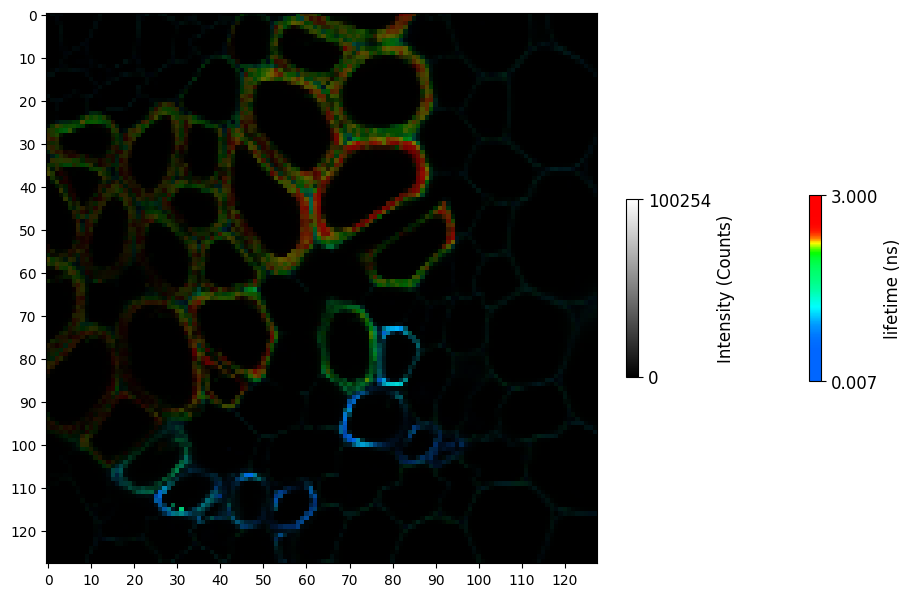

In [183]:
min_tau=0
max_tau=3
lifetimes_pruned = np.clip(lifetimes, min_tau, max_tau)


print(lifetimes_pruned.min())
print(lifetimes_pruned.max())
print("-----")
# lifetimes_range = lifetimes.max() - lifetimes.min()


lifetimes_norm = normalize_image(lifetimes_pruned)
print(lifetimes_norm.min())
print(lifetimes_norm.max())
print("-----")
#lifetimes_1_2 = lifetimes * 1.2 - lifetimes_range * 0.2

lifetimes_norm_spread = spread_distribution_without_dark_pixels(lifetimes_norm, intensities) * 0.6  #no violet colors please

print(lifetimes_norm_spread.min())
print(lifetimes_norm_spread.max())
print("-----")


lifetimes_norm_spread_inverted = 0.6 - lifetimes_norm_spread
#lifetimes_1_2 = lifetimes_norm_spread * 1.4 - 1 * 0.4

print(lifetimes_norm_spread_inverted.min())
print(lifetimes_norm_spread_inverted.max())
print("-----")



intensities_scaled = normalize_image(intensities)
#lifetimes_clipped = np.clip(lifetimes_1_2, 0, 0.6)

#print(lifetimes_clipped.min())
#print(lifetimes_clipped.max())
#print("-----")

#ipdb.set_trace()


# Create HSV and convert to RGB
saturations = np.ones((width, width), dtype=np.float64) * saturation
hsv = np.stack((lifetimes_norm_spread_inverted, saturations, intensities_scaled), axis=2)
rgb = skimage.color.hsv2rgb(hsv)
#bgr = rgb[..., ::-1]  # Invert colors

# Create a figure and axis
fig, ax = plt.subplots(figsize=(10, 10))

# Set extent to align pixel indices with the axes
img = ax.imshow(rgb, extent=[-0.5, width - 0.5, width - 0.5, -0.5])
# Add ticks every 10 pixels
x_ticks = np.arange(0, width, 10)
y_ticks = np.arange(0, width, 10)
ax.set_xticks(x_ticks)
ax.set_yticks(y_ticks)
ax.set_xticklabels(x_ticks)
ax.set_yticklabels(y_ticks)

# Create a custom colormap for Hue
sat = 1.0
val = 1.0
rgbs = []
hues = []
hue_increment = 0.01
for hue_i in range(101):
    hue = hue_i * hue_increment
    hues.append(hue)

#hues.insert(0, hues[0])  # Duplicate red values
#hues.insert(0, hues[0])  # Duplicate red values
#hues.insert(-1, hues[-1])  # Duplicate blue values
#hues.insert(-1, hues[-1])  # Duplicate blue values

#hues = hues[::-1]  # Invert colorbar


hues_spread = spread_data_to_distribution_without_dark_pixels(np.array(hues), lifetimes_norm, intensities)
#hues_spread = np.array(hues)
hues_spread = hues_spread * 0.6
hues_spread = 0.6 - hues_spread  # Invert colorbar

#hues_spread = hues_spread[::-1]  # Invert colorbar
for hue in hues_spread:
    #print(hue)
    hsv = np.array([hue, sat, val])
    rgb = skimage.color.hsv2rgb(hsv)
    rgbs.append(rgb)




hue_cmap = LinearSegmentedColormap.from_list("hue_cmap", rgbs)
hue_norm = plt.Normalize(vmin=0, vmax=1)
hue_sm = plt.cm.ScalarMappable(cmap=hue_cmap, norm=hue_norm)
hue_sm.set_array([])

cbar_hue = fig.colorbar(
    hue_sm,
    ax=ax,
    orientation="vertical",
    fraction=0.016,
    pad=0.22,
    aspect=15,
)
cbar_hue.set_label("lifetime (ns)", fontsize=12)
cbar_hue.ax.tick_params(labelsize=12)
cbar_hue.set_ticks([0, 1])  # Normalized range
lifetimes_min_ns = lifetimes_pruned.min()
lifetimes_max_ns = lifetimes_pruned.max()
cbar_hue.set_ticklabels([f"{lifetimes_min_ns:.3f}", f"{lifetimes_max_ns:.3f}"])

# Add colorbar for Value (intensity)
intensity_cmap = plt.cm.gray
intensity_norm = plt.Normalize(vmin=0, vmax=1)
intensity_sm = plt.cm.ScalarMappable(cmap=intensity_cmap, norm=intensity_norm)
intensity_sm.set_array([])
cbar_intensity = fig.colorbar(
    intensity_sm,
    ax=ax,
    orientation="vertical",
    fraction=0.020,
    pad=0.05,
    aspect=15,
)
max_intensity = int(np.max(intensities))
cbar_intensity.set_ticks([0, 1])
cbar_intensity.set_ticklabels([f"0", f"{int(max_intensity)}"])
cbar_intensity.set_label("Intensity (Counts)", fontsize=12)
cbar_intensity.ax.tick_params(labelsize=12)
plt.grid(False)
plt.show()
#return (hues_spread, lifetimes_norm_spread)

In [184]:
histograms.shape

(16384, 6252)

In [ ]:
import warnings
warnings.filterwarnings('ignore')
(hues_spread, lifetimes_norm_spread) = plot_histogram_as_tau_flim_and_intensity3(histograms, 16, min_tau = 0, max_tau = 6)

  0%|          | 0/16384 [00:00<?, ?it/s]

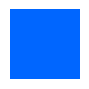

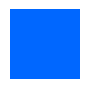

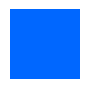

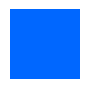

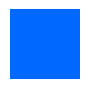

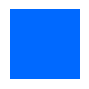

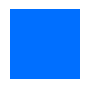

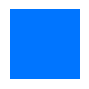

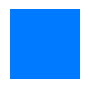

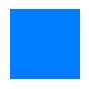

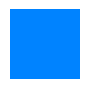

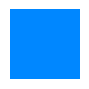

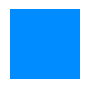

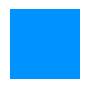

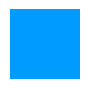

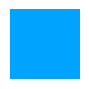

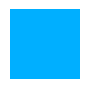

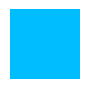

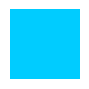

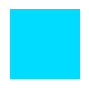

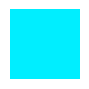

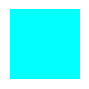

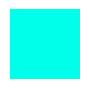

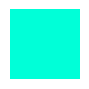

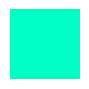

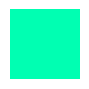

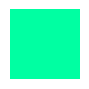

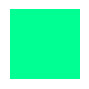

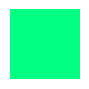

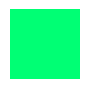

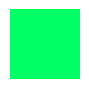

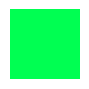

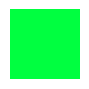

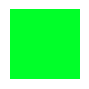

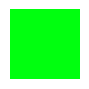

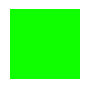

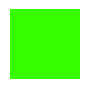

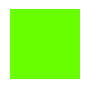

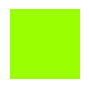

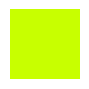

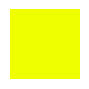

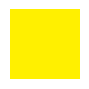

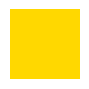

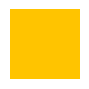

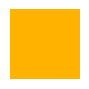

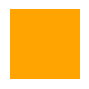

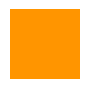

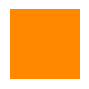

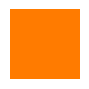

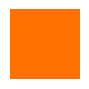

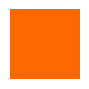

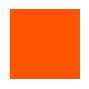

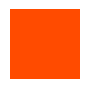

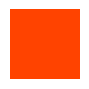

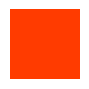

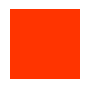

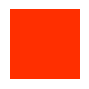

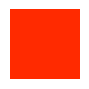

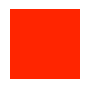

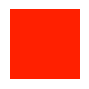

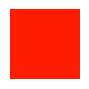

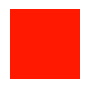

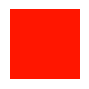

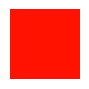

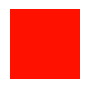

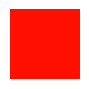

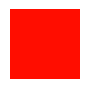

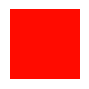

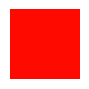

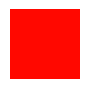

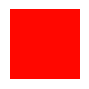

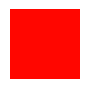

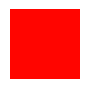

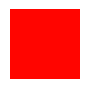

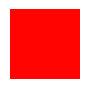

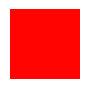

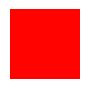

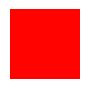

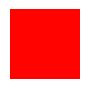

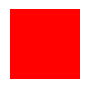

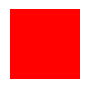

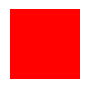

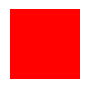

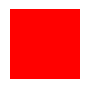

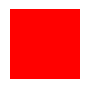

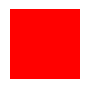

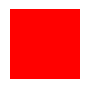

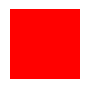

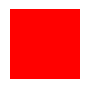

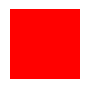

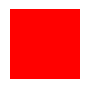

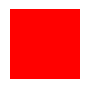

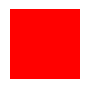

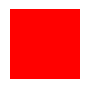

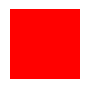

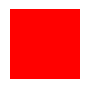

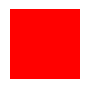

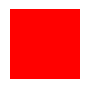

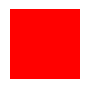

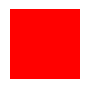

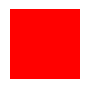

In [123]:
for hue in hues_spread:
    display_rgb_color(skimage.color.hsv2rgb([hue, 1, 1]))